In [1]:
import numpy as np
from scipy.special import factorial
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt
import scipy as sp
from matplotlib.colors import SymLogNorm
import sys
sys.path.append(r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection/StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D

20 phonons

In [2]:
nSiteData = np.load("nSite2DPlottingData.npz")
s_factor_nSite = nSiteData["s_tot"]
s_factor_nSite_incoh = nSiteData["s_diag"]
q_list_nSite = nSiteData["qlist"]
omega_list_nSite = nSiteData["omegalist"]*1e6

In [3]:
qplt, omgplt= np.meshgrid(q_list_nSite,omega_list_nSite)

x = np.linspace(0.01,200,500)
y = x**2/2/26161e3
qbz = np.pi/(2*np.pi/2.28)
qia = 2*np.sqrt(2*40e-6*26161e3)
x_log = np.logspace(-2, 2.3,500)
y_dm = x_log*1e-3 - x_log**2/(80e3)

In [4]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

Text(0.5, 0, '$q$ [keV]')

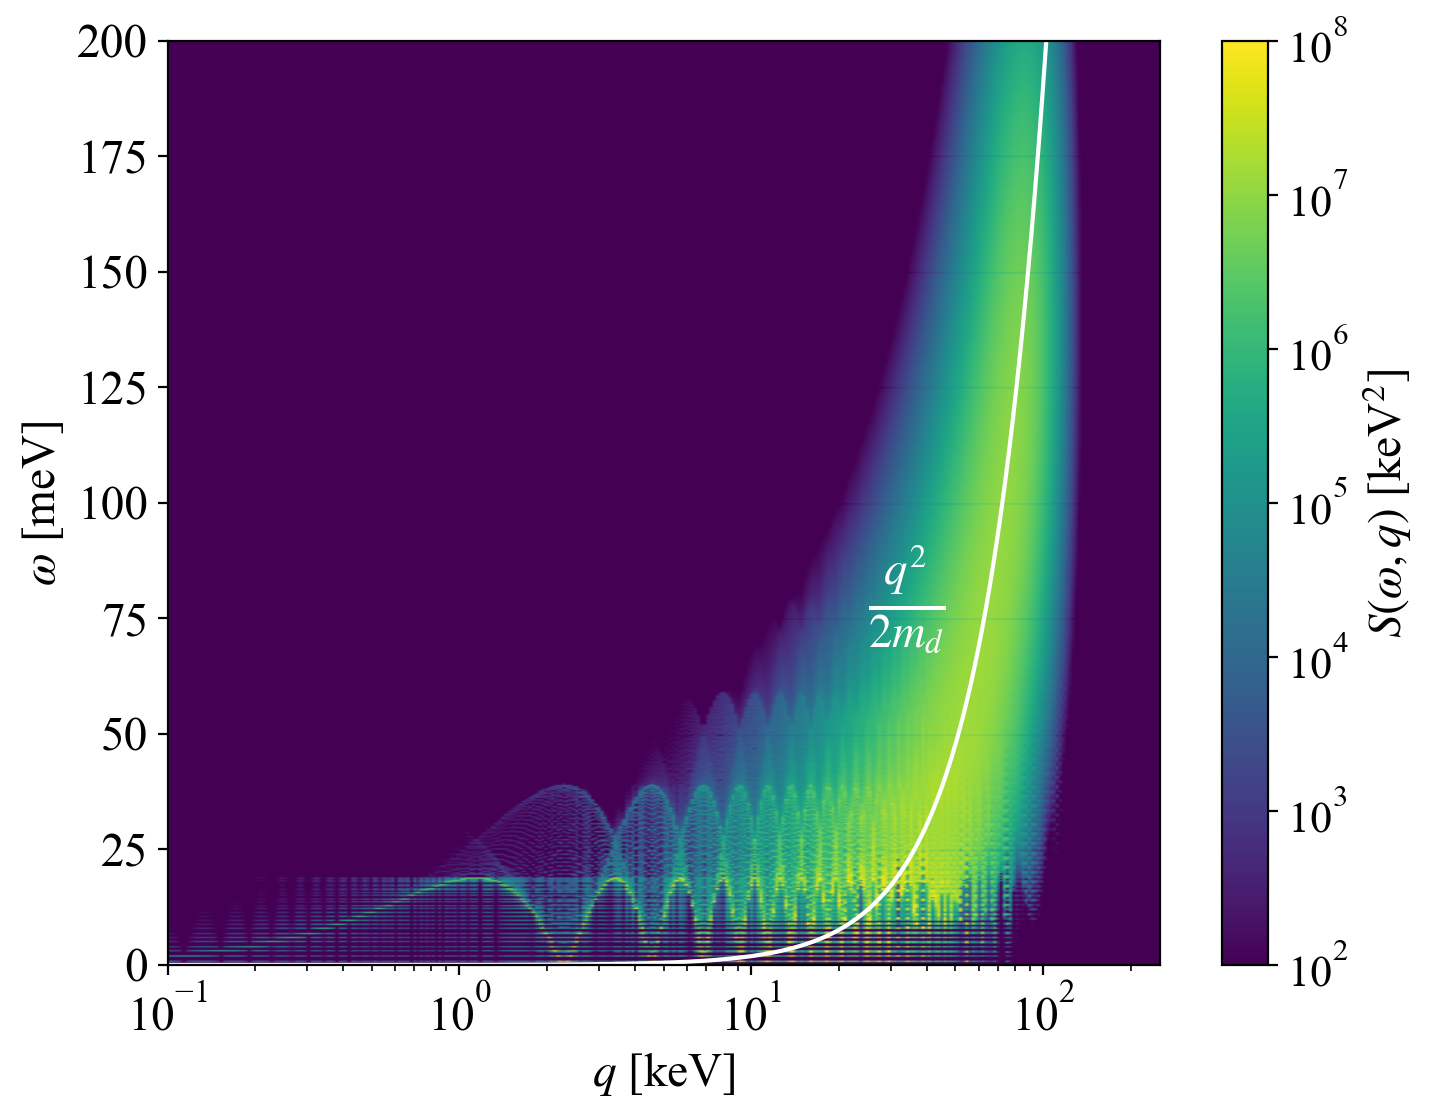

In [5]:
plt.figure(figsize=(8, 6),)
pcm = plt.pcolormesh(qplt, omgplt, s_factor_nSite.T,shading='gouraud',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("$S(\omega,q)$ [keV$^2$]")
cbar.ax.tick_params(labelsize=16)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
# plt.plot(x_log,y_dm*1e6, color='white', linestyle=":")
# plt.axvline(qbz,color="gray",linestyle="--",)
# plt.axvline(qia,color="gray",linestyle="--",)
# plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
# plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.xscale('log')
plt.xlim(1e-1,250)
plt.ylim(0,200)
plt.clim(1e2,1e8)
plt.text(25,75,r"$\frac{q^2}{2m_d}$",color="white",fontsize = 24)
plt.ylabel("$\omega$ [meV]")
plt.xlabel("$q$ [keV]")
 # plt.legend()
# plt.yscale('log')

Text(0.5, 1.0, 'Incoherent approximation')

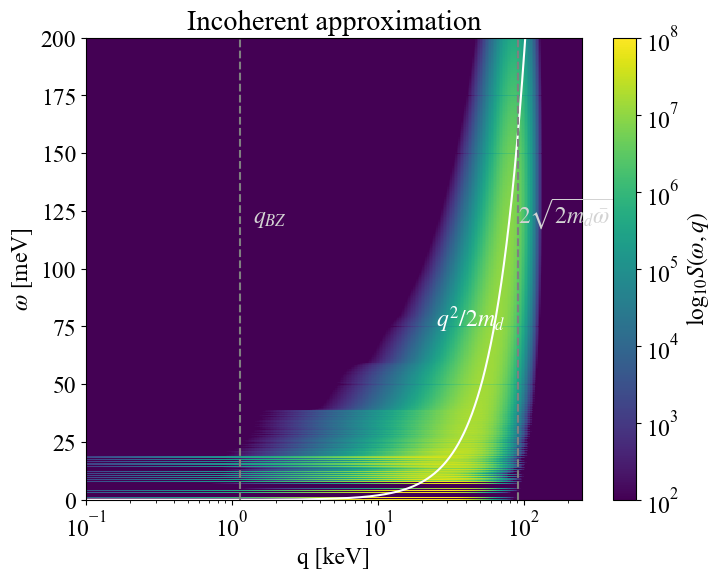

In [6]:
plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(qplt, omgplt, s_factor_nSite_incoh.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("log$_{10}S(\omega,q)$")
plt.xscale('log')
plt.clim(1e2,1e8)
plt.xlim(1e-1,250)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
plt.text(25,75,"$q^2/2m_d$",color="white")
plt.axvline(qbz,color="gray",linestyle="--",)
plt.axvline(qia,color="gray",linestyle="--",)
plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.ylabel("$\omega$ [meV]")
plt.ylim(0,200)
plt.xlabel("q [keV]")
plt.title("Incoherent approximation")
# plt.yscale('log')

In [7]:
def get_impulse_approx(q, omega_list, omega_avg=13.13e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

In [8]:
s_factor_IA = get_impulse_approx(q_list_nSite[:,np.newaxis], omega_list_nSite*1e-6, omega_avg=13.13e-6)
s_factor_IA.shape

(600, 700)

Text(0.5, 1.0, 'Impulse Approximation')

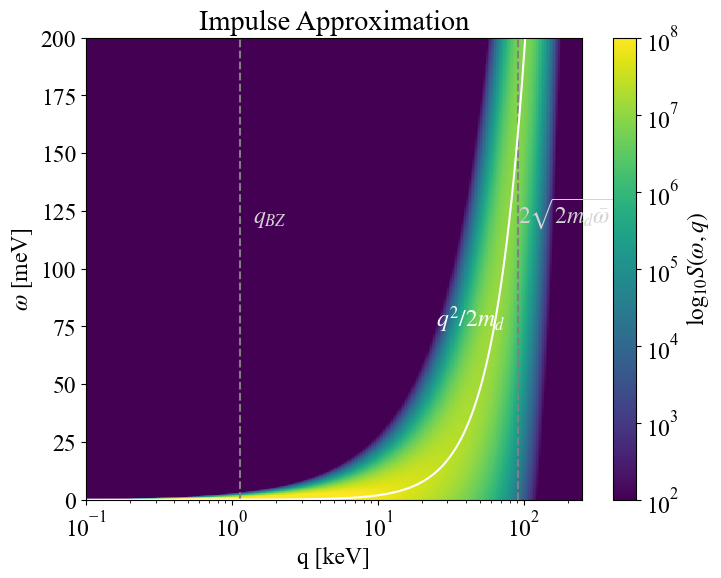

In [9]:
plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(qplt, omgplt, s_factor_IA.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("log$_{10}S(\omega,q)$")
plt.xscale('log')
plt.xlim(1e-1,250)
plt.axvline(qbz,color="gray",linestyle="--",)
plt.axvline(qia,color="gray",linestyle="--",)
plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.clim(1e2,1e8)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
plt.text(25,75,"$q^2/2m_d$",color="white")
plt.ylabel("$\omega$ [meV]")
plt.ylim(0,200)
plt.xlabel("q [keV]")
plt.title("Impulse Approximation")

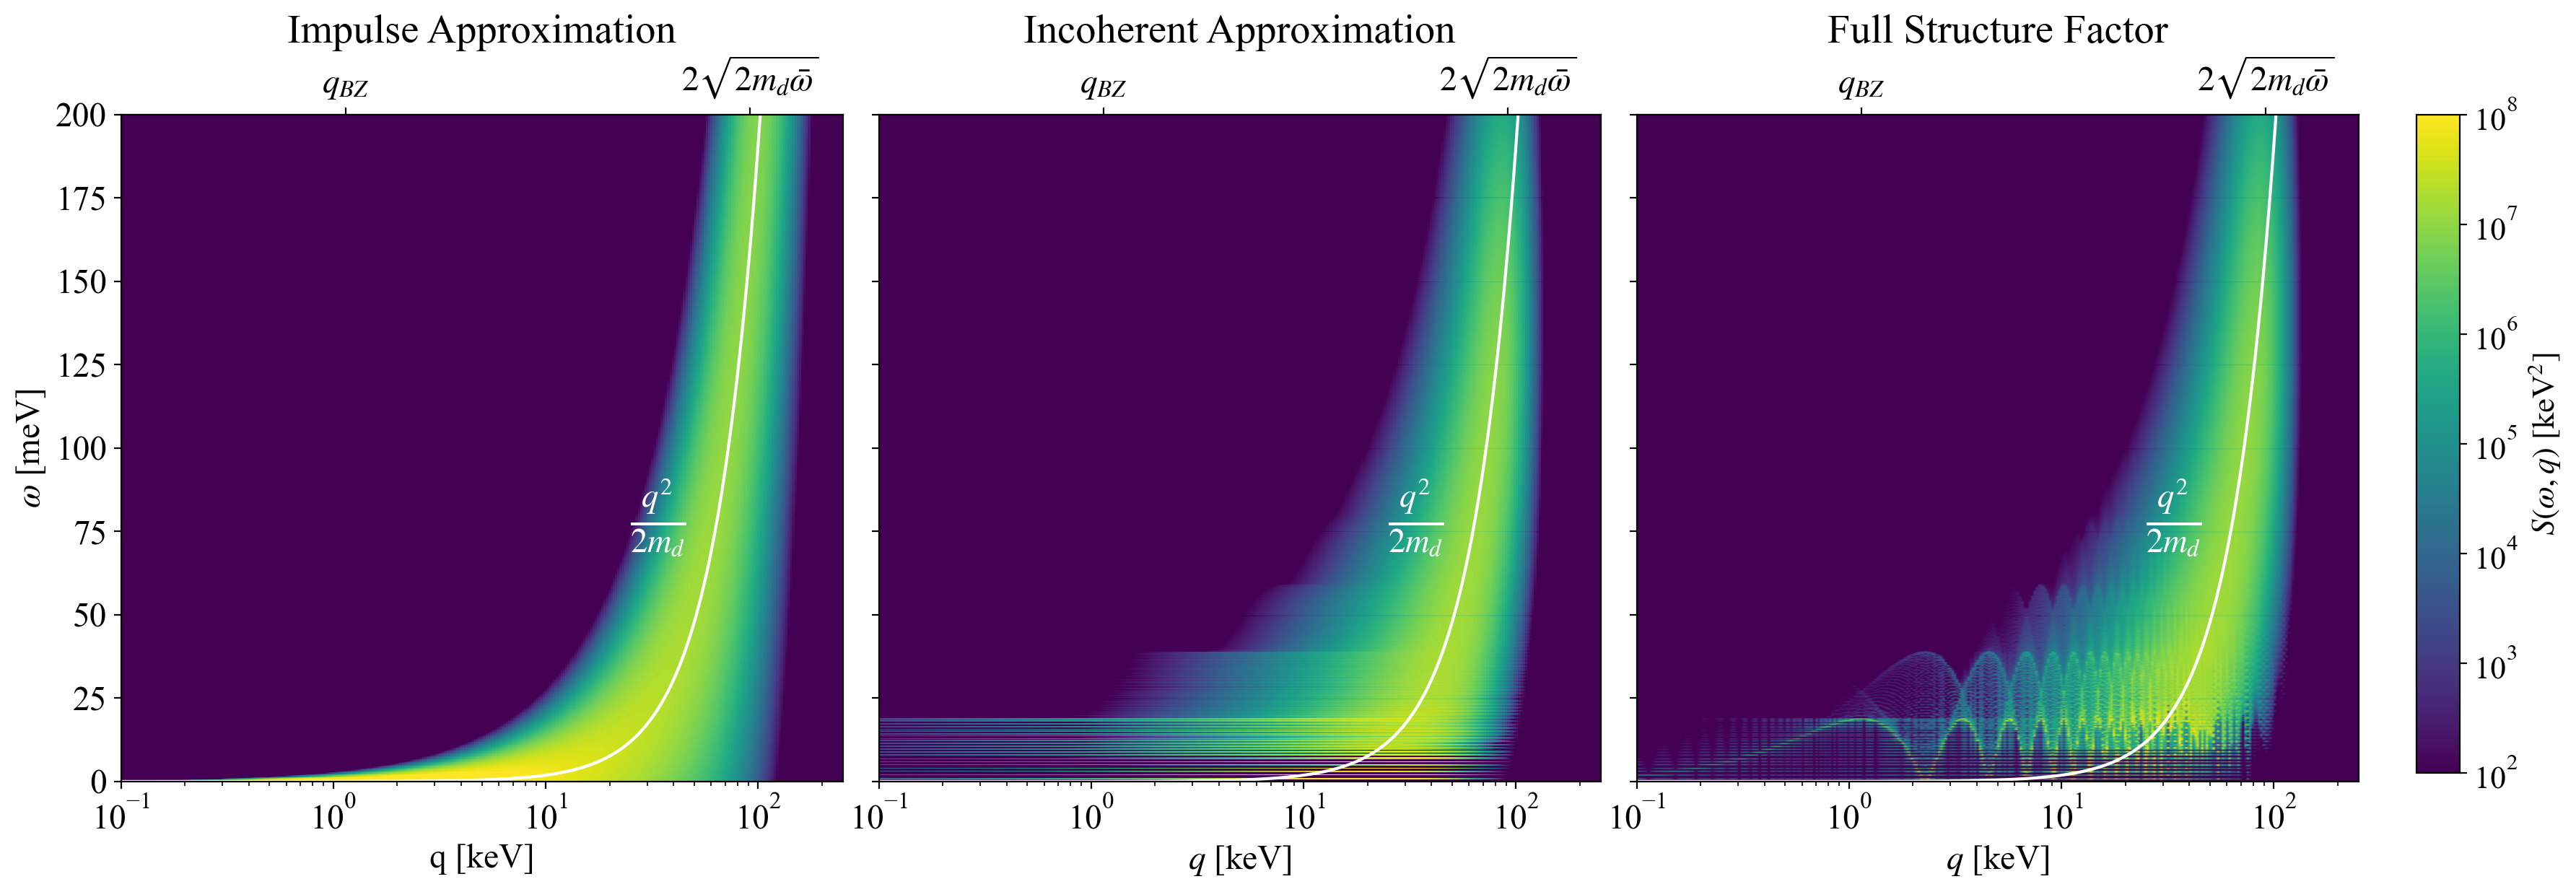

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True, dpi=200)

# Define shared normalization
norm = SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8)


pcm1 = axes[0].pcolormesh(qplt, omgplt, s_factor_IA.T, shading='nearest', norm=norm)
pcm1.set_clim(1e2, 1e8)
axes[0].set_xscale('log')
axes[0].set_xlim(1e-1, 250)
axes[0].set_ylim(0, 200)
axes[0].plot(x, y*1e6, color='white', label="q^2/2m")
axes[0].text(25, 75, r"$\frac{q^2}{2m_d}$", color="white",fontsize=24)

axes[0].set_ylabel(r"$\omega$ [meV]")
axes[0].set_xlabel("q [keV]")
axes[0].set_title("Impulse Approximation")


pcm2 = axes[1].pcolormesh(qplt, omgplt, s_factor_nSite_incoh.T, shading='nearest', norm=norm)
pcm2.set_clim(1e2, 1e8)
axes[1].set_xscale('log')
axes[1].set_xlim(1e-1, 250)
axes[1].set_ylim(0, 200)
axes[1].plot(x, y*1e6, color='white', label="q^2/2m")
axes[1].text(25, 75, r"$\frac{q^2}{2m_d}$", color="white",fontsize=24)

axes[1].set_xlabel("$q$ [keV]")
axes[1].set_title("Incoherent Approximation")



pcm3 = axes[2].pcolormesh(qplt, omgplt, s_factor_nSite.T, shading='gouraud', norm=norm)
pcm3.set_clim(1e2, 1e8)
axes[2].set_xscale('log')
axes[2].set_xlim(1e-1, 250)
axes[2].set_ylim(0, 200)
axes[2].plot(x, y*1e6, color='white', label="q^2/2m")
axes[2].text(25, 75, r"$\frac{q^2}{2m_d}$", color="white", fontsize=24)
axes[2].set_xlabel("$q$ [keV]")
axes[2].set_title('Full Structure Factor')



fig.subplots_adjust(wspace=0.05)

cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.76]) 

# Draw the colorbar into this specific axis
cbar = fig.colorbar(pcm3, cax=cbar_ax)
cbar.set_label("$S(\omega,q)$ [keV$^2$]", fontsize=16)
cbar.ax.tick_params(labelsize=16)


secax0 = axes[0].secondary_xaxis('top')
secax0.set_xticks([qbz, qia])
secax0.set_xticklabels([r"$q_{BZ}$", r"$2\sqrt{2m_d\bar{\omega}}$"])
secax0.minorticks_off()
secax0.tick_params(axis='x',)

secax1 = axes[1].secondary_xaxis('top')
secax1.set_xticks([qbz, qia])
secax1.set_xticklabels([r"$q_{BZ}$", r"$2\sqrt{2m_d\bar{\omega}}$"])
secax1.minorticks_off()
secax1.tick_params(axis='x',)

secax2 = axes[2].secondary_xaxis('top')
secax2.set_xticks([qbz, qia])
secax2.set_xticklabels([r"$q_{BZ}$", r"$2\sqrt{2m_d\bar{\omega}}$"])
secax2.minorticks_off()
secax2.tick_params(axis='x',)



plt.show()

Single phonon

In [27]:
nSiteData = np.load("nSite2DPlottingData_zoomin.npz")
s_factor_zoom = nSiteData["s_tot"]
s_factor_zoom_incoh = nSiteData["s_diag"]
q_list_zoom = nSiteData["qlist"]
omega_list_zoom = nSiteData["omegalist"]*1e6

In [28]:
x_zoom = np.linspace(0.0,5,400)
y_zoom = np.abs(2*10*np.sin(x_zoom*2*np.pi/2.28/2))

Text(0.5, 1.0, 'Coherent corrections')

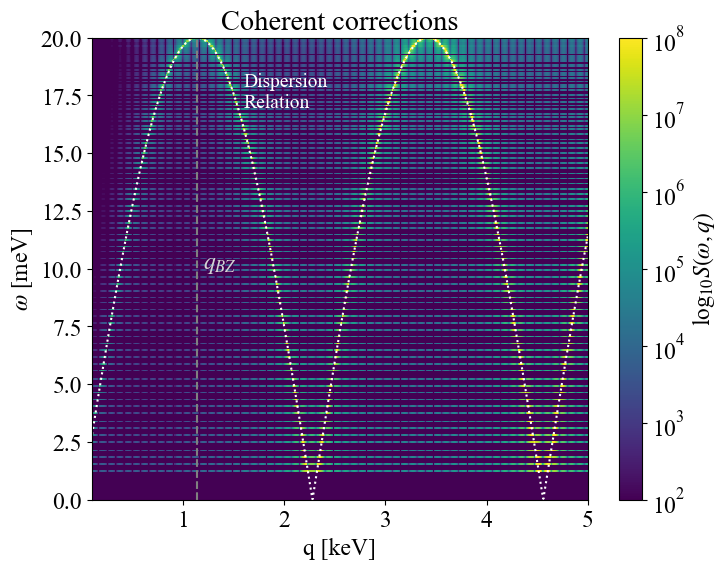

In [29]:
qplt_zoom, omgplt_zoom = np.meshgrid(q_list_zoom,omega_list_zoom)

plt.figure(figsize=(8, 6),dpi=100)
pcm = plt.pcolormesh(qplt_zoom, omgplt_zoom, s_factor_zoom.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
plt.clim(1e2,1e8)
cbar.set_label("log$_{10}S(\omega,q)$")
# plt.xscale('log')
plt.xlim(1e-1,5)
plt.ylim(0,20.0)
plt.axvline(qbz,color="gray",linestyle="--",)
plt.text(1.2,10,r"$q_{BZ}$",color="lightgray")
plt.plot(x_zoom,y_zoom, color="white",linestyle=":")
plt.text(1.6,17,"Dispersion\nRelation",color="white",fontsize=14)
plt.ylabel("$\omega$ [meV]")
plt.xlabel("q [keV]")
plt.title("Coherent corrections")

Text(0.5, 1.0, 'Incoherent approximation')

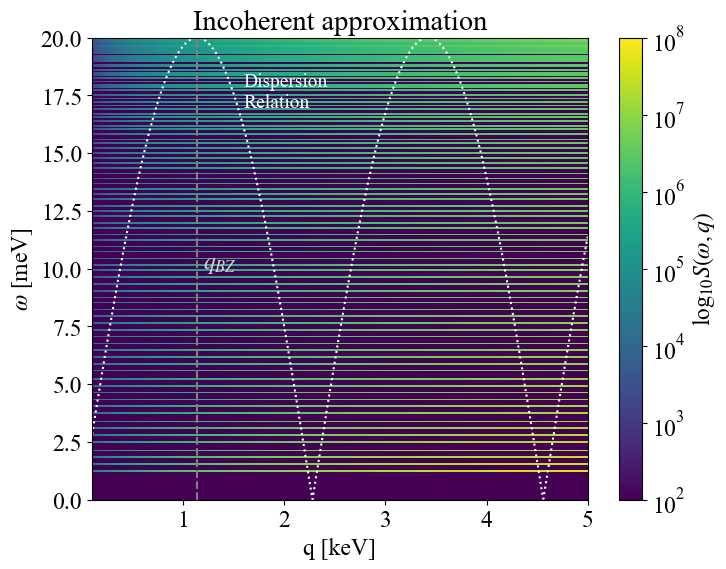

In [30]:
qplt_zoom, omgplt_zoom = np.meshgrid(q_list_zoom,omega_list_zoom)

plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(qplt_zoom, omgplt_zoom, s_factor_zoom_incoh.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("log$_{10}S(\omega,q)$")
# plt.xscale('log')
plt.xlim(1e-1,5)
plt.clim(1e2,1e8)
plt.ylim(0,20.0)
plt.axvline(qbz,color="gray",linestyle="--",)
plt.text(1.2,10,r"$q_{BZ}$",color="lightgray")
plt.plot(x_zoom,y_zoom, color="white",linestyle=":")
plt.text(1.6,17,"Dispersion\nRelation",color="white",fontsize=14)
plt.ylabel("$\omega$ [meV]")
plt.xlabel("q [keV]")
plt.title("Incoherent approximation")